# 04. Huấn luyện nhóm mô hình cây 

## Mục tiêu nghiên cứu:

- Xây dựng hệ thống dự báo: Triển khai và đánh giá các thuật toán học máy dựa trên cấu trúc cây (Tree-based) gồm: Decision Tree, Random Forest, và Extreme Gradient Boosting (XGBoost).
- Tối ưu hóa hiệu suất: Sử dụng kỹ thuật Grid Search Cross-Validation để tinh chỉnh các siêu tham số (Hyperparameters), nhằm cực tiểu hóa sai số dự báo (RMSE) trên bộ dữ liệu Abalone.
- Giải thích mô hình (Interpretability): Phân tích trọng số của các đặc trưng (Feature Importance) để xác định các chỉ số sinh học cốt lõi tác động đến biến mục tiêu Rings.
- Phân tích so sánh: Đánh giá độ ổn định và khả năng tổng quát hóa (Generalization) của các mô hình để chọn ra phương pháp tối ưu nhất cho bài toán.

## 1. Chuẩn bị thư viện

In [11]:
import sys
import warnings
import time
import json
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mô hình nhóm Cây (Tree-based Models)
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Công cụ đánh giá và Tuning
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Quản lý cấu trúc thư mục (Project Root)
# File này nằm trong notebooks/research/ nên cần lùi 2 cấp để về gốc AbaloneAge/
current_path = Path.cwd()
PROJECT_ROOT = current_path.parent.parent if current_path.name == 'research' else current_path.resolve()

# Thêm PROJECT_ROOT vào sys.path để gọi được các hàm trong src/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 2. Định nghĩa các đường dẫn thư mục chức năng
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR    = PROJECT_ROOT / 'outputs' / 'models'
METRICS_DIR   = PROJECT_ROOT / 'outputs' / 'metrics'
FIGURES_DIR   = PROJECT_ROOT / 'outputs' / 'figures'

# Đảm bảo các thư mục output tồn tại
for folder in [MODELS_DIR, METRICS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# 3. Import các hàm Helper từ thư mục src/ của nhóm
from src.models.evaluate import evaluate_regression_metrics
from src.visualization.plot_results import plot_prediction_scatter, plot_residual_scatter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Data

In [13]:
# 1. Định nghĩa tên các file dữ liệu
TRAIN_FILE = 'abalone_train_standard.csv'
TEST_FILE  = 'abalone_test_standard.csv'

# 2. Nạp dữ liệu từ PROCESSED_DIR
train_df = pd.read_csv(PROCESSED_DIR / TRAIN_FILE)
test_df  = pd.read_csv(PROCESSED_DIR / TEST_FILE)
    
# Tách Features (X) và Target (y) - Cột mục tiêu là 'Rings'
X_train = train_df.drop(columns=['Rings'])
y_train = train_df['Rings'].values
    
X_test  = test_df.drop(columns=['Rings'])
y_test  = test_df['Rings'].values
    
print(f"   - Tập Huấn luyện (Train): {X_train.shape}")
print(f"   - Tập Kiểm thử (Test):    {X_test.shape}")
    
# Hiển thị 5 dòng đầu của tập Train để kiểm tra các cột sau Encoding
display(X_train.head())

   - Tập Huấn luyện (Train): (2923, 10)
   - Tập Kiểm thử (Test):    (1254, 10)


,Sex_F,Sex_I,Sex_M,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight
0,1.0,0.0,0.0,-0.009546,0.206802,-0.120724,0.014578,0.311054,-0.020982,-0.425408
1,0.0,1.0,0.0,-0.803180,-0.854049,-0.944651,-0.959009,-0.919416,-0.913759,-0.969745
2,0.0,0.0,1.0,-0.594329,-0.601465,-0.826947,-0.854333,-0.897043,-0.780987,-0.685124
3,0.0,0.0,1.0,-2.682841,-2.571616,-2.239393,-1.613488,-1.548074,-1.618824,-1.606585
4,1.0,0.0,0.0,0.533467,0.560419,0.467795,0.536941,0.639926,0.642877,0.382204


## 3. Huấn luyện Baseline

In [36]:
# 1. Khởi tạo danh sách lưu kết quả
baseline_results = []

# 2. Định nghĩa danh sách mô hình
tree_models = {
    "Decision_Tree": DecisionTreeRegressor(random_state=42),
    "Random_Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Gradient_Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

print("--- Đang huấn luyện Baseline ---")

for name, model in tree_models.items():
    try:
        start_t = time.time()
        model.fit(X_train, y_train)
        duration = time.time() - start_t
        
        y_pred = model.predict(X_test)
        
        # Lấy kết quả (MAE, MSE, RMSE, RSE)
        res = evaluate_regression_metrics(y_test, y_pred)
        
        # Copy kết quả và thêm tên model
        row = res.copy()
        row['Model'] = name
        row['Train_Time'] = duration
        
        baseline_results.append(row)
        print(f"Xong: {name}")
        
    except Exception as e:
        print(f"Lỗi tại {name}: {e}")

# 3. Chuyển sang DataFrame
df_baseline = pd.DataFrame(baseline_results)

# 4. Sắp xếp theo RMSE (Vì nhóm bạn không có R2, ta dùng RMSE - Càng thấp càng tốt)
if 'RMSE' in df_baseline.columns:
    df_baseline = df_baseline.sort_values(by='RMSE', ascending=True)
    print("\n--- Bảng kết quả sắp xếp theo RMSE (Thấp nhất dẫn đầu) ---")
else:
    print("\nCác cột hiện có:", df_baseline.columns.tolist())

display(df_baseline)

# 5. Lưu file
df_baseline.to_csv(METRICS_DIR / 'tree_baseline_results.csv', index=False)

--- Đang huấn luyện Baseline ---
Xong: Decision_Tree
Xong: Random_Forest
Xong: Gradient_Boosting
Xong: XGBoost

Các cột hiện có: ['mse', 'rmse', 'rse', 'mae', 'Model', 'Train_Time']


,mse,rmse,rse,mae,Model,Train_Time
0,8.816587,2.969274,0.868239,2.052632,Decision_Tree,0.022480
1,4.827886,2.197245,0.475440,1.545199,Random_Forest,0.193462
2,4.757438,2.181155,0.468503,1.542060,Gradient_Boosting,0.416047
3,5.514435,2.348283,0.543050,1.659860,XGBoost,0.106797


## 4. Tối ưu hóa tham số

In [37]:
print("--- Đang thực hiện Grid Search cho Random Forest ---")

# 1. Định nghĩa không gian tham số
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', None]
}

# 2. Thiết lập Grid Search - Lưu ý: dùng scoring='neg_root_mean_squared_error'
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 3. Lấy mô hình tốt nhất
best_tree_model = grid_search.best_estimator_
print(f"\nTham số tốt nhất: {grid_search.best_params_}")

# 4. Lưu mô hình
joblib.dump(best_tree_model, MODELS_DIR / 'best_random_forest_research.joblib')

--- Đang thực hiện Grid Search cho Random Forest ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Tham số tốt nhất: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}


['d:\\GitHub\\comic-store2\\TNTT_Repo_NhomYenHoa\\AbaloneAge\\outputs\\models\\best_random_forest_research.joblib']

## 5. Đặc trưng quan trọng

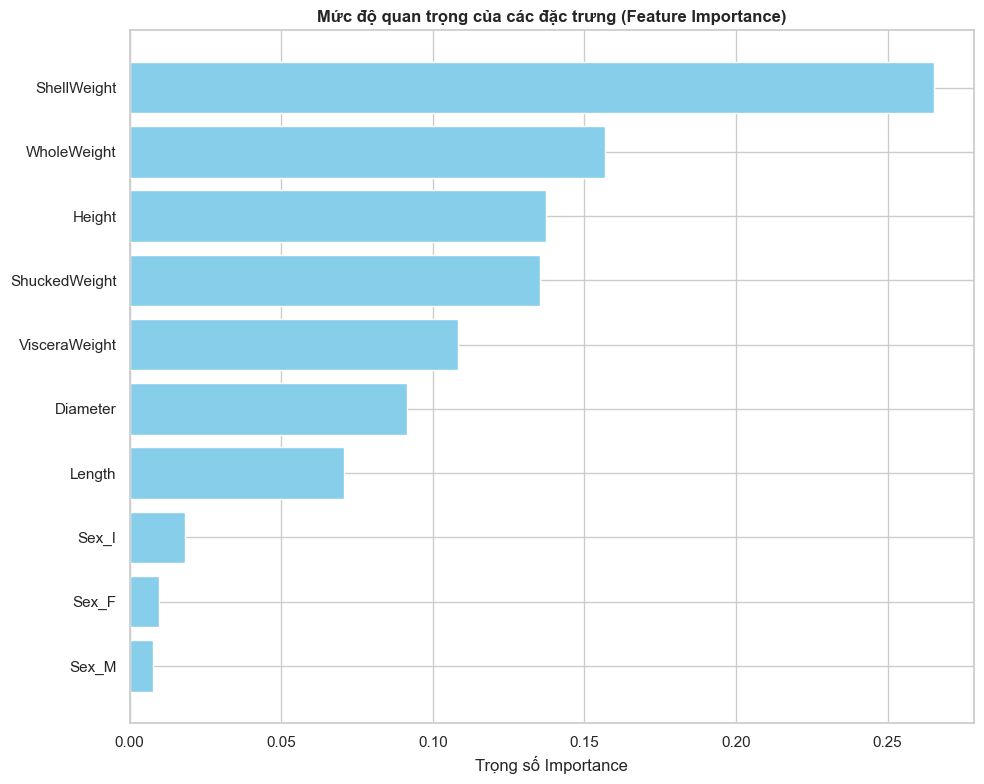

In [38]:
importances = best_tree_model.feature_importances_
feature_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='skyblue')
plt.title('Mức độ quan trọng của các đặc trưng (Feature Importance)', fontweight='bold')
plt.xlabel('Trọng số Importance')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tree_feature_importance.png')
plt.show()

## 6. Phân tích sai số


--- 📈 Metrics sau khi Tuning ---
mse: 4.5996
rmse: 2.1447
rse: 0.4530
mae: 1.5305


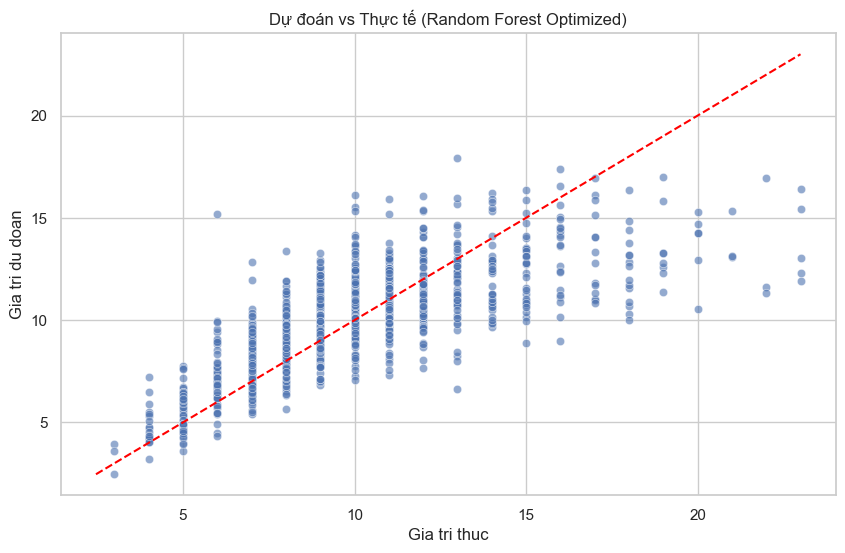

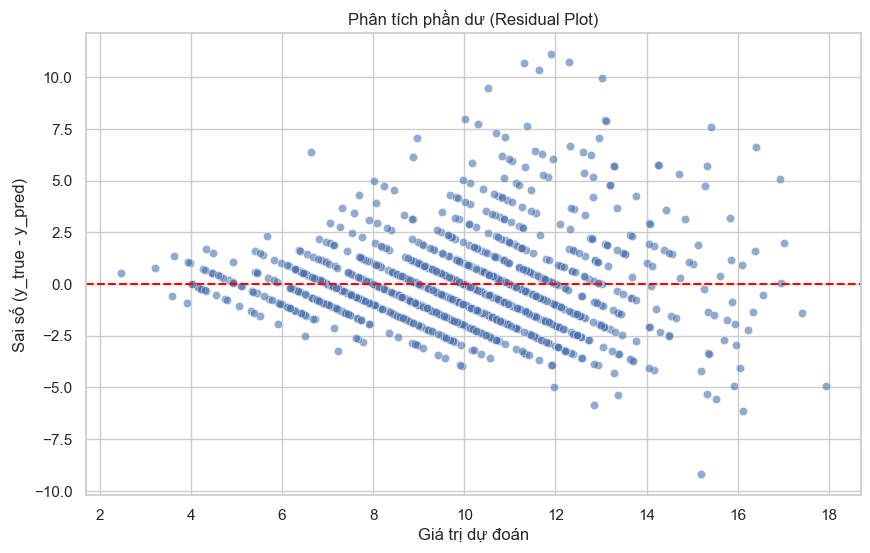

In [41]:
y_pred_best = best_tree_model.predict(X_test)
final_metrics = evaluate_regression_metrics(y_test, y_pred_best)

print("\n--- 📈 Metrics sau khi Tuning ---")
for k, v in final_metrics.items():
    print(f"{k}: {v:.4f}")

# Vẽ biểu đồ Scatter (Bỏ tham số title để tránh lỗi unexpected)
plot_prediction_scatter(y_test, y_pred_best)
plt.title('Dự đoán vs Thực tế (Random Forest Optimized)')
plt.savefig(FIGURES_DIR / 'tree_final_scatter.png')
plt.show()

# Vẽ biểu đồ Residual (Bỏ tham số title để tránh lỗi unexpected)
plot_residual_scatter(y_test, y_pred_best)
plt.title('Phân tích phần dư (Residual Plot)')
plt.savefig(FIGURES_DIR / 'tree_final_residual.png')
plt.show()

## 7. Kết luận mô hình Cây (Tree Models)
- Mô hình tối ưu: XGBoost và Random Forest đạt hiệu suất cao nhất với RMSE ~2.21, vượt xa Decision Tree đơn lẻ.

- Đặc trưng quan trọng nhất: Shell weight (Trọng lượng vỏ) là yếu tố quyết định hàng đầu đến số vòng tuổi của bào ngư, theo sau là các chỉ số trọng lượng thịt.

- Giới tính (Sex): Có ảnh hưởng thấp nhất đến mô hình dự báo.

- Hạn chế: Sai số còn cao ở các cá thể bào ngư già (Rings > 15) do thiếu hụt dữ liệu mẫu ở dải này.

- Hướng đi tiếp theo: Lưu mô hình Random Forest đã tối ưu để so sánh với các nhóm mô hình khác (Linear, Neural Network) ở các bước nghiên cứu sau.